# Importing Libraries

In [1]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras import layers
from tensorflow.keras.utils import plot_model

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Loading Dataset

In [2]:
data = pd.read_csv('/kaggle/input/hotel-rev/HTL.csv')

# Data Preprocessing

In [3]:
# Function to remove Arabic diacritics
arabic_diacritics = re.compile("""
                             ّ    | # Tashdid
                             َ    | # Fatha
                             ً    | # Tanwin Fath
                             ُ    | # Damma
                             ٌ    | # Tanwin Damm
                             ِ    | # Kasra
                             ٍ    | # Tanwin Kasr
                             ْ    | # Sukun
                             ـ     # Tatwil/Kashida
                         """, re.VERBOSE)

def remove_diacritics(text):
    text = re.sub(arabic_diacritics, '', text)
    return text

# Text preprocessing function
def clean_text(text):
    # Define lists to search for and replace specific characters and patterns
    search = ["أ","إ","آ","ة","_","-","/",".","،"," و "," يا ",'"',"ـ","'","ى",
              "\\",'\n', '\t','&quot;','?','؟','!']
    replace = ["ا","ا","ا","ه"," "," ","","",""," و"," يا",
               "","","","ي","",' ', ' ',' ',' ? ',' ؟ ', ' ! ']
    
    # Remove diacritics (tashkeel) using the remove_diacritics function
    text = remove_diacritics(text)
    
    # Reduce elongated characters to their original form (e.g., "جميل" <- "جمييييييييييييييييييل")
    longation = re.compile(r'(.)\1+')
    subst = r"\1\1"
    text = re.sub(longation, subst, text)
    
    # Remove non-alphanumeric characters, punctuation, and symbols
    text = re.sub(r"[^\w\s]", '', text)
    
    # Remove English letters
    text = re.sub(r"[a-zA-Z]", '', text)
    
    # Replace digits with a space
    text = re.sub(r"\d+", ' ', text)
    
    # Remove newline characters
    text = re.sub(r"\n+", ' ', text)
    
    # Remove tab characters
    text = re.sub(r"\t+", ' ', text)
    
    # Remove carriage return characters
    text = re.sub(r"\r+", ' ', text)
    
    # Replace multiple spaces with a single space
    text = re.sub(r"\s+", ' ', text)
    
    # Replace duplicated Arabic characters with a single instance (e.g., "وو" -> "و")
    text = text.replace('وو', 'و')
    text = text.replace('يي', 'ي')
    text = text.replace('اا', 'ا')
    
    # Replace specific characters defined in the search list with their respective replacements
    for i in range(0, len(search)):
        text = text.replace(search[i], replace[i])
    
    # Remove leading and trailing spaces
    text = text.strip()
    
    return text


In [4]:
# Filter only positive (1) and negative (-1) reviews
data = data[data.polarity.isin([-1, 1])]

# Apply text preprocessing/cleaning to the 'text' column and store cleaned text in a new column 'cleaned_text'
data['cleaned_text'] = data.text.apply(clean_text)

# Remove rows with empty string reviews in the 'cleaned_text' column
data = data[data.cleaned_text != ""]

# Calculate the minimum sample size from each polarity (positive and negative)
min_sample = data.groupby(['polarity']).count().text.min()

# Concatenate a balanced dataset with equal positive and negative samples
input_data = pd.concat([
    data[data.polarity == 1].head(min_sample),
    data[data.polarity == -1].head(min_sample)
])

# Count the number of samples for each polarity in the balanced dataset
input_data.groupby(['polarity']).count()

# Create numpy arrays for input (X) and output (Y)
X = input_data.cleaned_text.values  # Input features (cleaned text)
Y = np.asarray(input_data.polarity.values).astype('float32')  # Output labels (polarity)
Y = Y.clip(0, 1)  # Clip labels to 0 and 1

# Tokenization and sequence padding
num_words = 10000  # Maximum number of words to keep based on frequency
tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(X)  # Fit tokenizer on input text

X = tokenizer.texts_to_sequences(X)  # Convert text to sequences
vocab_size = len(tokenizer.word_index) + 1  # Vocabulary size (+1 for padding token)
print("vocab size:", vocab_size)  # Print the vocabulary size

# Set the maximum sequence length and pad sequences to a fixed length
maxlen = 300  # Maximum length of sequences
X = pad_sequences(X, padding='post', maxlen=maxlen)  # Pad sequences

# Store the fitted tokenizer for later use
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Split the data into training and testing sets
X_train, X_test, label_train, label_test = train_test_split(
    X, Y, test_size=0.3, random_state=42)


vocab size: 48682


# Create Model

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 300, 100)          1000000   
                                                                 
 bidirectional (Bidirection  (None, 300, 200)          160800    
 al)                                                             
                                                                 
 global_max_pooling1d (Glob  (None, 200)               0         
 alMaxPooling1D)                                                 
                                                                 
 dense (Dense)               (None, 128)               25728     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8

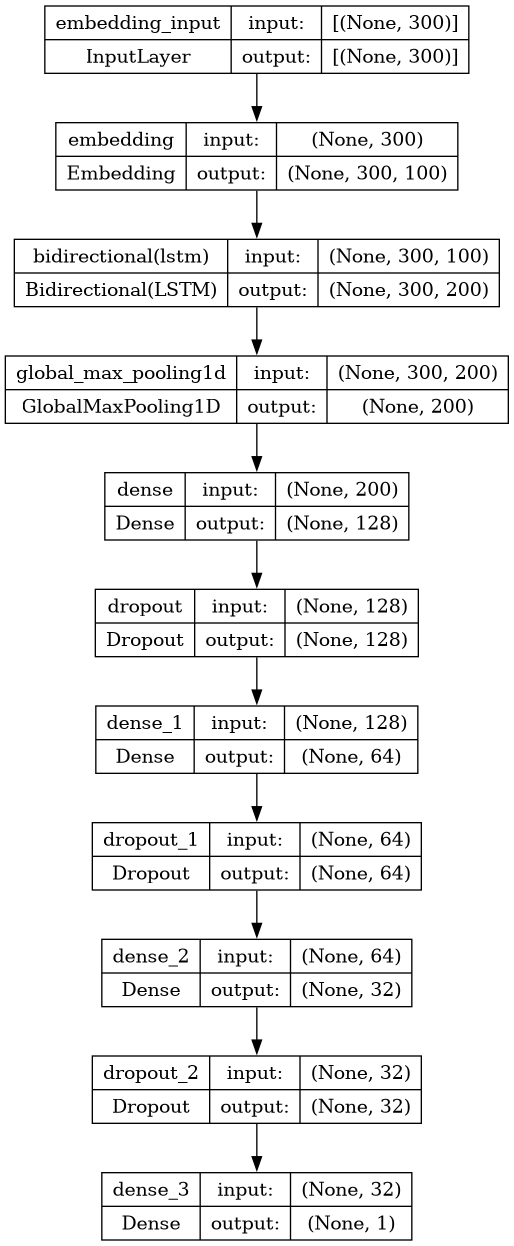

In [5]:
# Model configuration parameters
embedding_dim = 100  # Dimension of word embeddings
dropout = 0.5  # Dropout rate to prevent overfitting
opt = 'adam'  # Optimizer (Adam) for model compilation

# Sequential model creation
model = Sequential()

# Embedding Layer
model.add(layers.Embedding(input_dim=num_words,  # Size of the vocabulary
                           output_dim=embedding_dim,  # Dimension of word embeddings
                           input_length=maxlen))  # Length of input sequences

# Bidirectional LSTM Layer
model.add(layers.Bidirectional(layers.LSTM(100,  # Number of LSTM units
                                           dropout=dropout,  # Dropout rate for LSTM units
                                           recurrent_dropout=dropout,  # Dropout rate for recurrent connections
                                           return_sequences=True)))  # Return sequences for subsequent layers

# GlobalMaxPooling1D Layer
model.add(layers.GlobalMaxPool1D())  # Extracts the most relevant features by taking the maximum value across the sequence

# Dense Layers with Dropout
model.add(layers.Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(layers.Dropout(dropout))  # Dropout layer to prevent overfitting
model.add(layers.Dense(64, activation='relu'))  # Dense layer with ReLU activation
model.add(layers.Dropout(dropout))  # Dropout layer to prevent overfitting
model.add(layers.Dense(32, activation='relu'))  # Dense layer with ReLU activation
model.add(layers.Dropout(dropout))  # Dropout layer to prevent overfitting

# Output Layer
model.add(layers.Dense(1, activation='sigmoid'))  # Output layer with Sigmoid activation for binary classification

# Model Compilation
model.compile(optimizer=opt,  # Optimizer
              loss='binary_crossentropy',  # Binary cross-entropy loss function
              metrics=['accuracy'])  # Evaluation metric - accuracy

# Display model summary
model.summary()

# Plotting the model architecture
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)


In [6]:
# Model Training
history = model.fit(X_train, label_train,
                    epochs=4,  # Number of training epochs
                    verbose=True,  # Show training progress
                    validation_data=(X_test, label_test),  # Validation data for evaluation after each epoch
                    batch_size=64)  # Batch size for training

# Model Evaluation on Training Data
loss, accuracy = model.evaluate(X_train, label_train, verbose=True)  # Evaluate model on training data
print("Training Accuracy: {:.4f}".format(accuracy))  # Print training accuracy

# Model Evaluation on Testing Data
loss_val, accuracy_val = model.evaluate(X_test, label_test, verbose=True)  # Evaluate model on testing data
print("Testing Accuracy:  {:.4f}".format(accuracy_val))  # Print testing accuracy


Epoch 1/4
58/58 [==============================] - 140s 2s/step - loss: 0.6938 - accuracy: 0.5012 - val_loss: 0.6909 - val_accuracy: 0.4890
Epoch 2/4
58/58 [==============================] - 128s 2s/step - loss: 0.5921 - accuracy: 0.6859 - val_loss: 0.5182 - val_accuracy: 0.7461
Epoch 3/4
58/58 [==============================] - 127s 2s/step - loss: 0.3661 - accuracy: 0.8790 - val_loss: 0.2348 - val_accuracy: 0.9225
Epoch 4/4
116/116 [==============================] - 17s 149ms/step - loss: 0.1145 - accuracy: 0.9646
Training Accuracy: 0.9646
50/50 [==============================] - 7s 148ms/step - loss: 0.2399 - accuracy: 0.9168
Testing Accuracy:  0.9168


# Testing

In [7]:
def predict_sentiment(input_text):
    # Clean the input text using the 'clean_text' function
    cleaned_input = clean_text(input_text)
    
    # Convert the cleaned text to sequences using the fitted tokenizer
    sequence = tokenizer.texts_to_sequences([cleaned_input])
    
    # Pad the sequence to a fixed length for model input
    padded_sequence = pad_sequences(sequence, padding='post', maxlen=maxlen)
    
    # Perform sentiment prediction using the trained model
    prediction = model.predict(padded_sequence)
    
    # Determine the sentiment based on the prediction probability threshold (0.5)
    if prediction[0][0] >= 0.5:
        print(f"The sentiment of the statement '{input_text}' is Positive.")
    else:
        print(f"The sentiment of the statement '{input_text}' is Negative.")

# Take user input
user_input = input("Enter your statement in Arabic: ")
predict_sentiment(user_input)


Enter your statement in Arabic:  منزل رائع


1/1 [==============================] - 1s 623ms/step
The sentiment of the statement 'منزل رائع' is Positive.
